# Debugging Constraint Violations

1/29

The purpose is to compute the score functions from the kinetic energy and obstacle avoidance terms, to better understand why the obstacle avoidance constraint non-satisfaction might be happening. At the very least, I will visualize the optimization process for a simple problem where I expect this conflict-of-interest to occur. Then I'll investigate how the penetration depth is impacted by $\sigma$ and the kinetic energy weight. Further considerations are contingent on the results of these tests.

In [1]:
%load_ext autoreload
%autoreload 2

import sys

from pathlib import Path

path = Path("..").resolve().as_posix()
if str(path) not in sys.path:
    sys.path.insert(0, str(path))

<string>:14: RuntimeWarning: invalid value encountered in divide
<string>:32: RuntimeWarning: invalid value encountered in divide


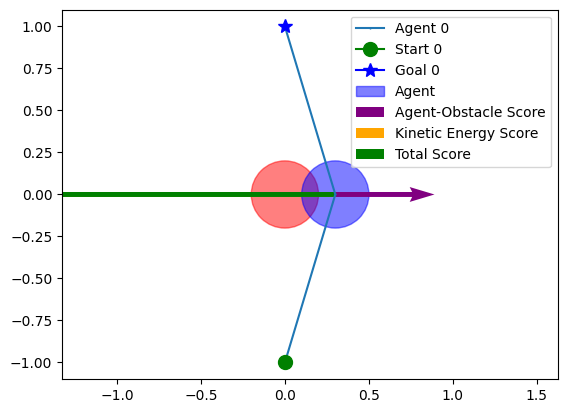

In [85]:
from matplotlib.axes import Axes
from ael.score_function import (
    compute_agent_obstacle_score_from_problem,
    compute_kinetic_energy_score,
)
import matplotlib.pyplot as plt
from ael.problem import Problem
from ael.visualize import visualize
import numpy as np


def show_result(
    problem: Problem, trajectory, sigma, score_obs, score_kin, score_total, agent_pos
):
    # Plot the score.
    ax: Axes = plt.gca()
    visualize(problem, ax, trajectory)
    ax.add_patch(
        plt.Circle(
            (agent_pos[0, 0], agent_pos[0, 1]),
            sigma,
            color="blue",
            alpha=0.5,
            label="Agent",
        )
    )
    ax.quiver(
        agent_pos[:, 0],
        agent_pos[:, 1],
        score_obs[:, 0],
        score_obs[:, 1],
        scale=5.0,
        width=0.01,
        color="purple",
        label="Agent-Obstacle Score",
    )
    ax.quiver(
        agent_pos[:, 0],
        agent_pos[:, 1],
        score_kin[:, 0],
        score_kin[:, 1],
        scale=5.0,
        width=0.01,
        color="orange",
        label="Kinetic Energy Score",
    )
    ax.quiver(
        agent_pos[:, 0],
        agent_pos[:, 1],
        score_total[:, 0],
        score_total[:, 1],
        scale=5.0,
        width=0.01,
        color="green",
        label="Total Score",
    )
    ax.axis("equal")
    ax.legend()
    plt.show()


def run(variable_x: float, sigma: float, kinetic_energy_weight: float):
    problem = Problem[np.ndarray](
        num_timesteps=3,
        agent_start_positions=np.array([[0.0, -1.0]]),
        agent_end_positions=np.array([[0.0, 1.0]]),
        agent_reference_trajectory=None,
        agent_radii=np.array([0.05]),
        agent_max_speeds=np.array([0.05]),
        obstacle_positions=np.array([[0.0, 0.0]]),
        obstacle_radii=np.array([0.2]),
    )
    trajectory = np.array([[[0.0, -1.0]], [[variable_x, 0.0]], [[0.0, 1.0]]])

    score_T_A_O_D, score_T_A1_A2_D = compute_agent_obstacle_score_from_problem(
        problem, trajectory, sigma=sigma, n_integral=20
    )
    score_kinetic = (
        compute_kinetic_energy_score(trajectory, sigma=sigma) * kinetic_energy_weight
    )

    # Isolate the t=1 scores for plotting.

    score_obs = score_T_A_O_D[1, :, 0, :]
    score_kin = score_kinetic[1, :, :]
    score_total = score_obs + score_kin
    agent_pos = trajectory[1, :, :]

    show_result(
        problem, trajectory, sigma, score_obs, score_kin, score_total, agent_pos
    )


run(variable_x=0.3, sigma=0.2, kinetic_energy_weight=50)
